<a href="https://colab.research.google.com/github/ezenio01YT/PRA3024-notebook/blob/main/GW_tutorial_3_modeled_searches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [ ]:
pip install pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.7 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver 

In [ ]:
%matplotlib inline
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import random

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

Saving aligo_O4high.txt to aligo_O4high.txt


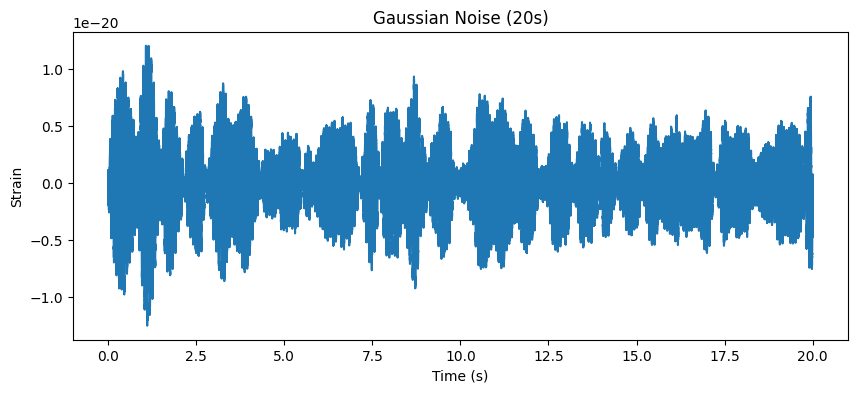

In [ ]:
import matplotlib.pyplot as plt
import pycbc.psd
import pycbc.noise
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

duration = 20
sample_rate = 4096
min_f = 12

delta_t = 1.0 / sample_rate
delta_f = 1.0 / duration
nyquist_freq = sample_rate / 2
psd_len = int(nyquist_freq / delta_f) + 1
ts_len = int(duration / delta_t)

psd = pycbc.psd.from_txt(
    filename,
    psd_len,
    delta_f,
    min_f,
    is_asd_file=True
)

noise_data = pycbc.noise.gaussian.noise_from_psd(
    length=ts_len,
    delta_t=delta_t,
    psd=psd,
    seed=None
)

plt.figure(figsize=(10, 4))
plt.plot(noise_data.sample_times, noise_data)
plt.title("Gaussian Noise (20s)")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.show()


As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

Max Amplitude of Original: 5.9742339442238295e-22
Max Amplitude of Projected: 3.50276809080686e-22


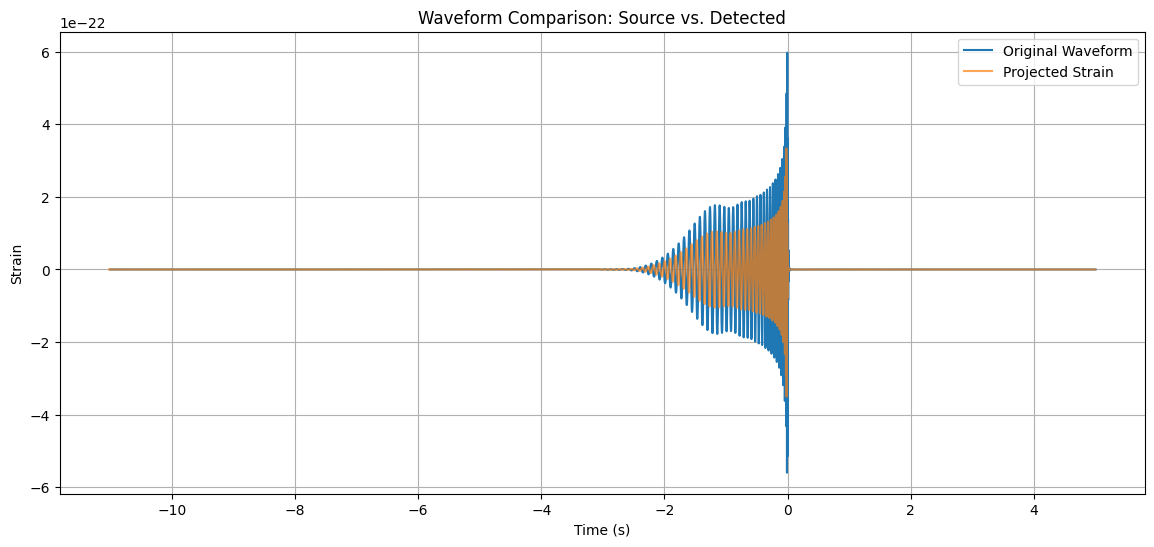

In [46]:
# Parameters from the exercise
m1 = 50           # Solar masses
m2 = 50           # Solar masses
distance = 2000   # Megaparsecs
approximant = "IMRPhenomD"

"""
Generate the waveform
"""
plus_p, cross_p = get_td_waveform(approximant=approximant,
                                  mass1=m1,
                                  mass2=m2,
                                  distance=distance,
                                  f_lower=min_f,
                                  delta_t=delta_t)

"""
Project onto detector (LIGO Livingston)
"""
# Generate random sky location and polarization using the ranges from the hint.
ra = np.random.uniform(0, 2 * np.pi)
dec = np.random.uniform(-2 * np.pi, 2 * np.pi)
pol = np.random.uniform(0, 2 * np.pi)

# Initialize the detector.
detector_name = "L1"    # LIGO Livingston
detector = Detector(detector_name)

# Project the waveform.
plus_p_projected = detector.project_wave(plus_p, cross_p,
                                     ra, dec, pol)

"""
Answer the Questions
"""
print(f"Max Amplitude of Original: {max(np.abs(plus_p))}")
print(f"Max Amplitude of Projected: {max(np.abs(plus_p_projected))}")

"""
Plotting and comparison
"""
plt.figure(figsize=(14, 6))

plt.plot(plus_p.sample_times, plus_p, label='Original Waveform')
plt.plot(plus_p_projected.sample_times, plus_p_projected,
         label=f'Projected Strain', alpha=0.7)

plt.title(f"Waveform Comparison: Source vs. Detected")
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid(True)
plt.show()


**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


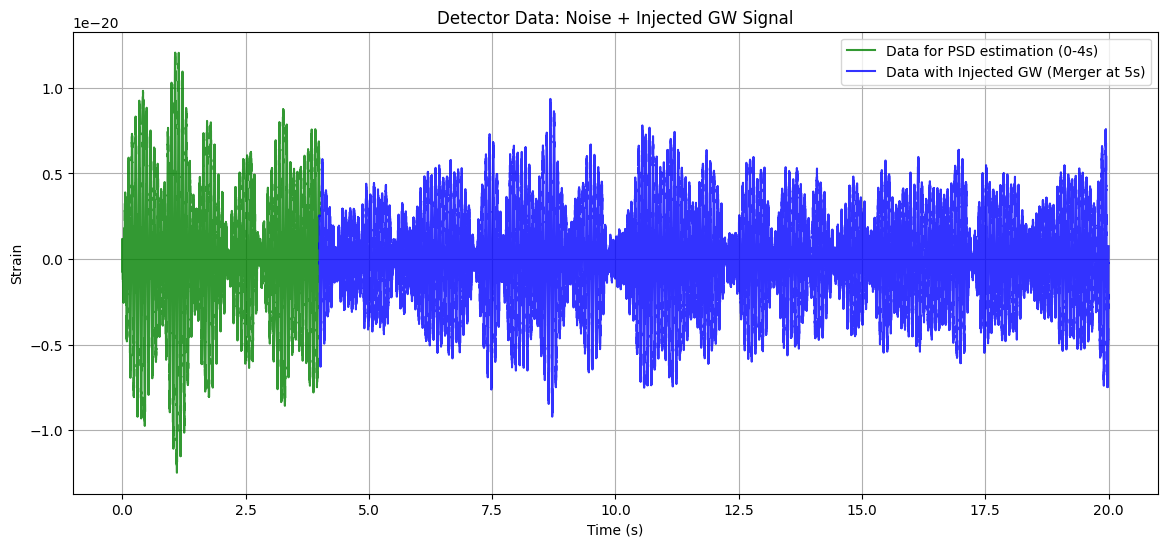

In [ ]:

"""
Resize the waveform to match the noise data length
"""
# Create a copy such that the original 'plus_p_projected' variable doesn't get modified.
gw_signal = plus_p_projected.copy()
gw_signal.resize(len(noise_data))

"""
Shift the waveform to the 5-second mark
"""
gw_signal = gw_signal.cyclic_time_shift(5.0)

# Ensure the start times align perfectly for addition.
gw_signal.start_time = noise_data.start_time

"""
Create the total data (noise + signal)
"""
total_data = noise_data + gw_signal

"""
Define the segments for the plot
"""
# Segment for PSD estimation: first 4 seconds.
psd_part = total_data.time_slice(0, 4)

# Segment where GW is added: the rest of the data (after 4s).
signal_part = total_data.time_slice(4, 20)


"""
Generate the overlaid plot
"""
pylab.figure(figsize=(14, 6))

# Plot the PSD estimation part (0-4s).
pylab.plot(psd_part.sample_times, psd_part,
           label='Data for PSD estimation (0-4s)', color='green', alpha=0.8)

# Plot the signal part (>4s).
pylab.plot(signal_part.sample_times, signal_part,
           label='Data with Injected GW (Merger at 5s)', color='blue', alpha=0.8)

pylab.title("Detector Data: Noise + Injected GW Signal")
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend(loc='upper right')
pylab.grid(True)
pylab.show()

**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


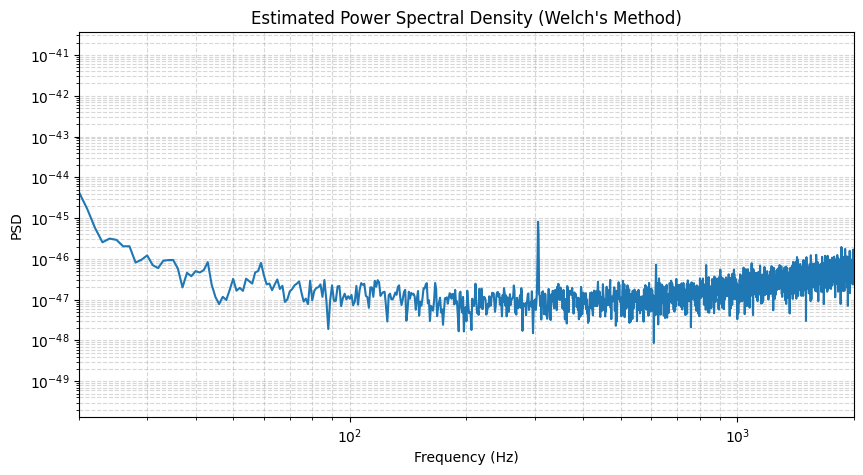

1. Delta_f of the estimated PSD: 1.0 Hz
2. Delta_f of the data: 0.05 Hz


In [ ]:
"""
Slice the data
"""
noise_segment = total_data.time_slice(0, 4)

"""
Define Welch's method parameters
"""
# The sample rate is 4096 Hz.
# Setting seg_len to 4096 samples means each segment is exactly 1 second long.
seg_len = 4096
seg_stride = int(seg_len / 2)

"""
Estimate the PSD
"""
# Used the Welch method to average overlapping segments.
estimated_psd = pycbc.psd.welch(noise_segment,
                                seg_len=seg_len,
                                seg_stride=seg_stride)

"""
Plot the estimated PSD
"""
plt.figure(figsize=(10, 5))
plt.loglog(estimated_psd.sample_frequencies, estimated_psd, label='Estimated PSD (Welch)')
plt.title("Estimated Power Spectral Density (Welch's Method)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.xlim(20, 2000)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

"""
Answer the questions
"""
print(f"1. Delta_f of the estimated PSD: {estimated_psd.delta_f} Hz")
print(f"2. Delta_f of the data: {total_data.delta_f} Hz")

Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

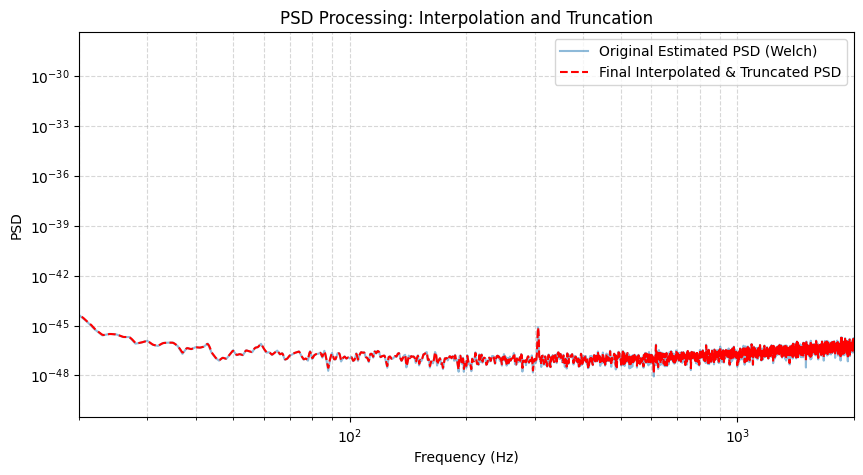

Old Delta_f: 1.0 Hz
New Delta_f: 0.05 Hz


In [ ]:
"""
Interpolate the PSD
"""
# The length of the new PSD will automatically be calculated to match the new delta_f.
interpolated_psd = pycbc.psd.interpolate(estimated_psd,
                                         total_data.delta_f)

"""
Inverse Spectrum Truncation
"""
# This step smooths the PSD and limits the duration of the impulse response to
# prevent 'wrap-around' corruption during whitening.

# Calculate max_filter_len based on the hint (4 * sampling rate).
max_filter_len = 4 * 4096

# Apply the truncation
# The hint also specifies a low_frequency_cutoff of 12 Hz.
psd = pycbc.psd.inverse_spectrum_truncation(interpolated_psd,
                                            max_filter_len=max_filter_len,
                                            low_frequency_cutoff=12,
                                            trunc_method='hann')

"""
Plot to compare
"""
plt.figure(figsize=(10, 5))

# Plot the original coarse estimate from Welch's method.
plt.loglog(estimated_psd.sample_frequencies, estimated_psd,
           label='Original Estimated PSD (Welch)', alpha=0.5)

# Plot the final processed PSD.
plt.loglog(psd.sample_frequencies, psd,
           label='Final Interpolated & Truncated PSD', color='red', linestyle='--')

plt.title("PSD Processing: Interpolation and Truncation")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.xlim(20, 2000)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

"""
Verification
"""
print(f"Old Delta_f: {estimated_psd.delta_f} Hz")
print(f"New Delta_f: {psd.delta_f} Hz")

Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

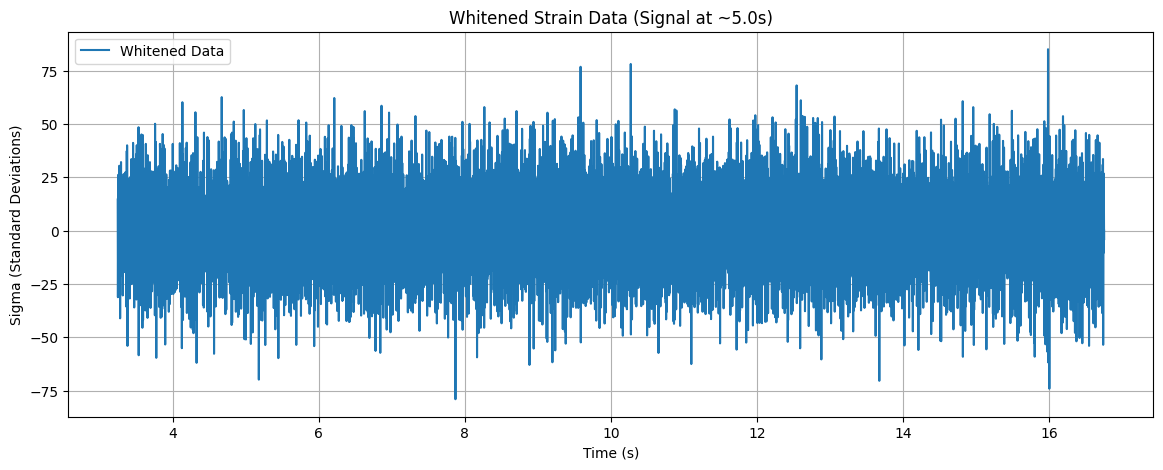

In [ ]:
"""
Reset: Generating the frequency series from the original data
"""
data_f = total_data.to_frequencyseries()

"""
Whiten the data
"""
# Converting to frequency series and divide by the ASD.
# Formula: sqrt(PSD)
data_f = total_data.to_frequencyseries()
whitened_f = data_f / psd**0.5

# Zero out low frequencies to avoid division-by-zero errors (everything below 30
# Hz).
k_min = int(30.0 / whitened_f.delta_f)
whitened_f[:k_min] = 0.0
whitened_f[len(whitened_f)-1] = 0.0

# Converting back to time domain.
whitened = whitened_f.to_timeseries()

"""
Crop the data
"""
# The exercise asks to crop 5s, but since your signal is at t=5s, only crop 3s
# to avoid deleting the signal.
whitened = whitened.crop(3, 3)

"""
Bandpass filter
"""
# Applying the highpass (30Hz) and lowpass (300Hz) filters.
whitened = whitened.highpass_fir(30, 512)
whitened = whitened.lowpass_fir(300, 512)

"""
Plot the result
"""
plt.figure(figsize=(14, 5))
plt.plot(whitened.sample_times, whitened, label='Whitened Data')

plt.title("Whitened Strain Data (Signal at ~5.0s)")
plt.xlabel("Time (s)")
plt.ylabel("Sigma (Standard Deviations)")
plt.legend()
plt.grid(True)
plt.show()

So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

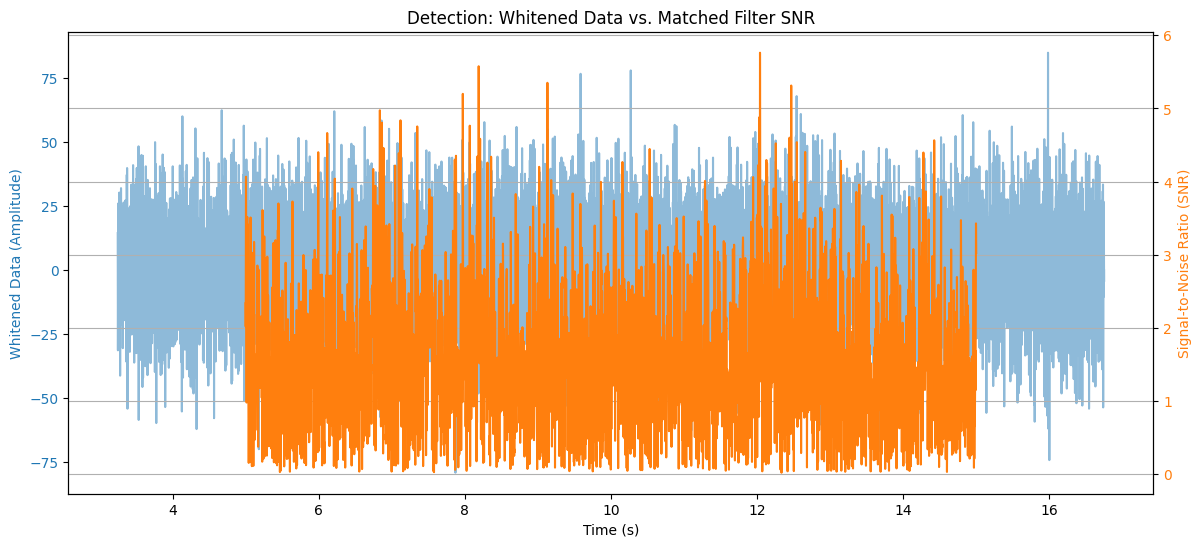

Maximum SNR: 5.76
Trigger Generated: YES (SNR > 5)


In [ ]:
"""
Prepare the template
"""
# Use the original waveform 'plus_p' generated in Exercise 2.
# Resize it to match the data length (20s) and sample rate.
template = plus_p.copy()
template.resize(len(total_data))

# The template needs to be cyclically shifted so the start of the waveform
# aligns with the start of the data buffer.
template = template.cyclic_time_shift(template.start_time)

"""
Run the matched filter
"""
snr = pycbc.filter.matchedfilter.matched_filter(template, total_data,
                     psd=psd,
                     low_frequency_cutoff=30)

"""
Crop the SNR time series
"""
# Cropping 5s from the beginning and 5s from the end.
snr = snr.crop(5, 5)

"""
Plotting
"""
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plotting Whitened Data (left axis).
color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Whitened Data (Amplitude)', color=color)
ax1.plot(whitened.sample_times, whitened, color=color, alpha=0.5, label='Whitened Data')
ax1.tick_params(axis='y', labelcolor=color)

# Plotting SNR (right axis).
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Signal-to-Noise Ratio (SNR)', color=color)
# SNR is a complex number (amplitude + phase), we plot the absolute value (magnitude).
ax2.plot(snr.sample_times, abs(snr), color=color, label='SNR')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Detection: Whitened Data vs. Matched Filter SNR")
plt.grid(True)
plt.show()

"""
Answer the Questions
"""
max_snr = max(np.abs(snr))
print(f"Maximum SNR: {max_snr:.2f}")

if max_snr > 5:
    print("Trigger Generated: YES (SNR > 5)")
else:
    print("Trigger Generated: NO")

Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.